# Neural Network

## Introduction


*  In fact, Logistic Regression (that have learned in our last session) is the simplest form of Neural Network; Artificial neural networks can be viewed as an extension of Logistic Regression
*  Logistic Regression: results in decision boundaries that are a straight line
*  Neural Networks: can generate more complex decision boundaries
*  (Deep) Neural Networks: a universal approximator!
* In this session, we will learn to use TensorFlow Keras for digit recgonization


## Importing the libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Libraries for deep learning
- **NumPy**: numerical computations and array manipulation.
- **Pandas**: loading CSV data.
- **Matplotlib**: visualizing images and plots.
- **PyTorch**: deep learning framework for building and training neural networks.
  - `torch.nn` provides neural network layers and loss functions.
  - `torch.optim` contains optimization algorithms.
  - `torch.utils.data` offers data loading utilities.

## Importing the dataset

- MNIST is a collection of handwritten digits ranging from the number 0 to 9. 

- It has a training set of 60,000 images, and 10,000 test images that are classified into corresponding categories or labels. 

In [2]:
# load dataset from local CSV files
train_data = pd.read_csv('mnist_train.csv')
test_data = pd.read_csv('mnist_test.csv')

# separate labels and pixel values
y_train = train_data['label'].values
x_train = train_data.drop('label', axis=1).values
y_test = test_data['label'].values
x_test = test_data.drop('label', axis=1).values

# normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# reshape to (num_samples, 28, 28) if needed for visualization, but keep flattened for model
# x_train_flat = x_train  # already flattened (784)
# x_test_flat = x_test

In [3]:
# count the number of unique train labels
unique, counts = np.unique(y_train, return_counts=True)
print("Train labels: ", dict(zip(unique, counts)))

# count the number of unique test labels
unique, counts = np.unique(y_test, return_counts=True)
print("\nTest labels: ", dict(zip(unique, counts)))

Train labels:  {np.int64(0): np.int64(600), np.int64(1): np.int64(600), np.int64(2): np.int64(600), np.int64(3): np.int64(600), np.int64(4): np.int64(600), np.int64(5): np.int64(600), np.int64(6): np.int64(600), np.int64(7): np.int64(600), np.int64(8): np.int64(600), np.int64(9): np.int64(600)}

Test labels:  {np.int64(0): np.int64(100), np.int64(1): np.int64(100), np.int64(2): np.int64(100), np.int64(3): np.int64(100), np.int64(4): np.int64(100), np.int64(5): np.int64(100), np.int64(6): np.int64(100), np.int64(7): np.int64(100), np.int64(8): np.int64(100), np.int64(9): np.int64(100)}


- Let's sample the 25 random MNIST digits and visualize them.

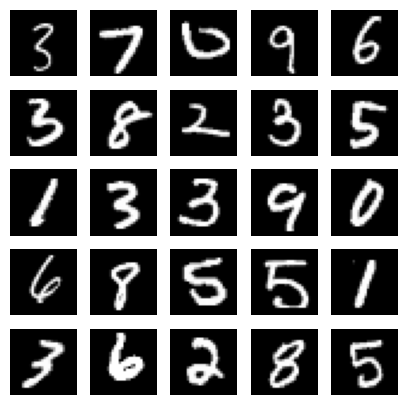

In [4]:
# sample 25 mnist digits from train dataset
indexes = np.random.randint(0, x_train.shape[0], size=25)
images = x_train[indexes]
labels = y_train[indexes]

# plot the 25 mnist digits
plt.figure(figsize=(5,5))
for i in range(len(indexes)):
    plt.subplot(5, 5, i + 1)
    image = images[i].reshape(28, 28)  # reshape flattened vector to 28x28 image
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    
plt.show()

### Data exploration
Visualizing a sample of images helps us understand the data and verify that loading and reshaping are correct.
- Each image is a grayscale 28×28 pixel grid.
- Labels are integers from 0 to 9.
- The dataset is balanced (approximately equal number of samples per class).

## Designing model architecture using PyTorch

## Import PyTorch modules

In [1]:
# Create PyTorch DataLoader for efficient batch loading
# TensorDataset wraps the feature tensors and label tensors together
train_dataset = TensorDataset(torch.tensor(x_train, dtype=torch.float32),
                              torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(x_test, dtype=torch.float32),
                             torch.tensor(y_test, dtype=torch.long))

# DataLoader shuffles the training data and loads batches
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Training batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

In [5]:
# PyTorch model definition will be provided below

## Compute the number of labels

## One-Hot Encoding  
- At this point, the labels are in digits format, 0 to 9.  
- In PyTorch, we typically use integer labels (0-9) with `CrossEntropyLoss`, which internally applies softmax and computes cross-entropy.  
- Therefore, we keep labels as integers and do not convert to one-hot vectors.

## Data Preprocessing 

In [8]:
# image dimensions (assumed square)
# MNIST images are 28x28 pixels, but data is flattened (784 columns)
image_size = int(np.sqrt(x_train.shape[1]))  # 28
input_size = image_size * image_size  # 784
input_size

784

In [9]:
# reshape to flat vector (already flattened, but ensure shape)
x_train = np.reshape(x_train, [-1, input_size])
x_test = np.reshape(x_test, [-1, input_size])

- The **batch_size** argument indicates the number of data that we will use for each update of the model parameters.

- **Hidden_units** shows the number of hidden units.

- **Dropout** is the dropout rate (related to **Overfitting and Regularization**).

In [10]:
# network parameters
batch_size = 128
hidden_units = 256
dropout = 0.45

### MNIST dataset
- **60,000 training images**, **10,000 test images**.
- Each image is a handwritten digit (0‑9) of size 28×28 pixels.
- Pixel values range from 0 (black) to 255 (white).
- The CSV format: first column is the label, the remaining 784 columns are the flattened pixel values.

## Data visualization

In [6]:
num_labels = len(np.unique(y_train))

In [7]:
# For PyTorch, we keep labels as integers (not one-hot)
# y_train and y_test are already integer labels

## Setting network parameters

In [11]:
# Convert data to PyTorch tensors and create DataLoader
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create TensorDataset and DataLoader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Designing the model architecture

### Neural network basics
A multilayer perceptron (MLP) consists of:
1. **Input layer**: 784 neurons (one per pixel).
2. **Hidden layers**: fully‑connected (dense) layers with activation functions (ReLU) and dropout for regularization.
3. **Output layer**: 10 neurons (one per digit) producing raw logits.

**Activation functions** introduce non‑linearity, allowing the network to learn complex patterns.
**Dropout** randomly deactivates neurons during training to prevent overfitting.

In [12]:
# Define a 3-layer MLP with ReLU and dropout after each layer
class MLP(nn.Module):
    def __init__(self, input_size, hidden_units, num_classes, dropout_rate):
        super(MLP, self).__init__()
        # First hidden layer
        self.fc1 = nn.Linear(input_size, hidden_units)
        # Second hidden layer
        self.fc2 = nn.Linear(hidden_units, hidden_units)
        # Output layer
        self.fc3 = nn.Linear(hidden_units, num_classes)
        # Dropout layer for regularization
        self.dropout = nn.Dropout(dropout_rate)
        
    def forward(self, x):
        # Flatten input image (already flattened, but keep for clarity)
        x = x.view(x.size(0), -1)
        # First layer: linear + ReLU + dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        # Second layer: linear + ReLU + dropout
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        # Output layer (logits, no activation)
        x = self.fc3(x)
        return x

# Instantiate the model
num_labels = 10  # digits 0-9
model = MLP(input_size, hidden_units, num_labels, dropout).to(device)
print(f'Model moved to {device}')

Using device: cpu


## View model summary  
- PyTorch does not have a built-in summary method like Keras, but we can print the model architecture and manually compute parameter counts.  
- The `print(model)` shows the layers and their shapes.

In [13]:
# Print model architecture
print(model)

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

MLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.45, inplace=False)
)
Total parameters: 269,322
Trainable parameters: 269,322


## How big is our model (number of parameters)?

- From input to Dense layer: 784 × 256 + 256 = 200,960. 

- From first Dense to second Dense: 256 × 256 + 256 = 65,792. 

- From second Dense to the output layer: 10 × 256 + 10 = 2,570. 

- The total is 200,690 + 65,972 + 2,570 = 269,322.

## Define loss function and optimizer  
- In PyTorch, we define a loss function (criterion) and an optimizer separately.  
- The loss function measures how far the model's predictions are from the true labels.  
- The optimizer updates the model's weights to minimize the loss.

In [14]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

## Loss function (CrossEntropyLoss)  
- `CrossEntropyLoss` combines softmax activation and negative log‑likelihood.  
- It expects raw logits (unnormalized scores) from the model and integer target labels (0‑9).  
- This is equivalent to `categorical_crossentropy` in Keras when using one‑hot labels.

## Optimization (Adam optimizer)  
- Adam is an adaptive learning‑rate optimization algorithm that works well for many deep‑learning tasks.  
- It combines ideas from RMSProp and momentum.  
- We pass the model parameters (`model.parameters()`) and a learning rate to the optimizer.

## Metrics (accuracy)  
- Accuracy is the fraction of correctly classified samples.  
- During training we compute accuracy per epoch to monitor progress.  
- In PyTorch we compute accuracy manually by comparing predicted class indices with true labels.

## Training loop  
- Unlike Keras’s `fit()`, PyTorch requires a manual training loop.  
- Each epoch iterates over the DataLoader, computes forward pass, loss, backward pass, and optimizer step.  
- We also track training loss and accuracy for visualization.

### Training process
The training loop implements the core steps of supervised learning:

1. **Forward pass**: compute predictions from input data.
2. **Loss computation**: measure error between predictions and true labels.
3. **Backward pass**: compute gradients of the loss with respect to each parameter (backpropagation).
4. **Optimization step**: update weights using the gradients (Adam optimizer).

We repeat these steps for multiple epochs, each time iterating over batches of data.

In [15]:
# Training loop
epochs = 20
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()  # set model to training mode (enables dropout)
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Iterate over batches
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        # Move data to the same device as the model
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # Compute epoch metrics
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100.0 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

print('Training finished.')

Epoch 1/1 - loss: 1.3502 - accuracy: 0.5933


## Evaluating model performance  
- After training, we evaluate the model on the test set.  
- We set the model to evaluation mode (`model.eval()`) to disable dropout and batch normalization.  
- No gradient computation is needed during evaluation, which saves memory and speeds up inference.

In [16]:
# Evaluate on test set
model.eval()  # set model to evaluation mode (disables dropout)
test_loss = 0.0
correct = 0
total = 0

# No gradient computation needed for evaluation
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Accumulate loss
        test_loss += loss.item()
        
        # Compute accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Average test loss and accuracy
test_loss /= len(test_loader)
test_accuracy = 100.0 * correct / total

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test loss: 0.6819
Test accuracy: 0.8190 (81.9%)


## Neural Network from scratch

- It's for the code session!

## Acknowledgments

Thanks to PRASHANT BANERJEE for creating the open-source [Kaggle jupyter notebook](https://www.kaggle.com/code/prashant111/mnist-deep-neural-network-with-keras), licensed under Apache 2.0. It inspires the majority of the content of this slides.